In [3]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np

# Libreria para graficos
from matplotlib import pyplot

import pandas as pd

# Modulo de optimizacion en scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [4]:
# Cargar dataset con pandas (sin usar datos de prueba en entrenamiento)
CSV_PATH = os.path.join('Dataset2', 'Dat2.csv')
df = pd.read_csv(CSV_PATH, sep=';')  # ✅ Especificar separador punto y coma

# Separar características y etiqueta
feature_cols = [c for c in df.columns if c not in ['id', 'target']]
X_all = df[feature_cols].values

# Convertir etiquetas a numerales (ej.: "Class_1" -> 1)
target_str = df['target'].astype(str).str.strip()
y_raw = target_str.str.extract(r'(\d+)$')[0]
if y_raw.isna().any():
    raise ValueError('No se pudo extraer número de alguna etiqueta en target')
y_raw = y_raw.astype(int)

# Configuración de etiquetas para entrenamiento:
#   label_shift = 0   -> clases 1..9
#   label_shift = -1  -> clases 0..8
label_shift = -1  # ✅ Cambiar a -1 para que clases sean 0..8 (indices)

# Etiquetas numéricas finales
y_all = (y_raw + label_shift).values
classes = sorted(np.unique(y_all).tolist())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}

num_labels = len(classes)
input_layer_size = X_all.shape[1]
m_total = X_all.shape[0]

print(f'Dataset cargado: m={m_total}, n={input_layer_size}, clases={classes[0]}..{classes[-1]} (K={num_labels})')

Dataset cargado: m=61877, n=93, clases=0..8 (K=9)


In [5]:
print (X_all[0,:])
print (y_raw)

[ 1  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  2  0  0  0  0  1  0  4
  1  1  0  0  2  0  0  0  0  0  1  0  0  0  0  1  0  5  0  0  0  0  0  2
  0  0  0  0  0  1  0  0  2  0  0 11  0  1  1  0  1  0  7  0  0  0  1  0
  0  0  0  0  0  0  2  1  0  0  0  0  1  0  0  0  0  0  0  0  0]
0        1
1        1
2        1
3        1
4        1
        ..
61872    9
61873    9
61874    9
61875    9
61876    9
Name: 0, Length: 61877, dtype: int64


In [6]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [7]:
# Split 80% entrenamiento / 20% prueba (sin fuga de información)
rng = np.random.default_rng(42)
idx = rng.permutation(m_total)
train_size = int(0.8 * m_total)
train_idx = idx[:train_size]
test_idx = idx[train_size:]

X_train = X_all[train_idx]
y_train = y_all[train_idx]
X_test = X_all[test_idx]
y_test = y_all[test_idx]

# Normalización usando SOLO entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm = (X_test - mu) / sigma

print(f'Train: {X_train_norm.shape}, Test: {X_test_norm.shape}')

Train: (49501, 93), Test: (12376, 93)


In [8]:
# Configurar matriz para entrenamiento (el sesgo se agrega dentro de OneVsAllOM)
m, n = X_train_norm.shape
X = X_train_norm
y = y_train

In [9]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

In [10]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [11]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [12]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de usar theta como parámetro para la regresión logística regularizada y
    el gradiente del costo w.r.t. a los parámetros.

    Parametros
    ----------
    theta : array_like
        Parametro theta de la regresion logistica. Vector de la forma(shape) (n, ). n es el numero de caracteristicas
        incluida la intercepcion

    X : array_like
        Dataset con la forma(shape) (m x n). m es el numero de ejemplos, y n es el numero de
        caracteristicas (incluida la intercepcion).

    y : array_like
        El conjunto de etiquetas. Un vector con la forma (shape) (m, ). m es el numero de ejemplos

    lambda_ : float
        Parametro de regularización.

    Devuelve
    -------
    J : float
        El valor calculado para la funcion de costo regularizada.

    grad : array_like
        Un vector de la forma (shape) (n, ) que es el gradiente de la
        función de costo con respecto a theta, en los valores actuales de theta..
    """
#     alpha = 0.003
#     theta = theta.copy()
    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    temp = theta
    temp[0] = 0

#     J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
#     theta = theta - (alpha / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad
#    return J, theta

In [13]:
def OneVsAll(X, y, classes, lambda_):
    alpha = 0.01
    num_iters = 100000

    m, n = X.shape
    num_labels = len(classes)
    all_theta = np.zeros((num_labels, n + 1))

    # Agrega unos a la matriz X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for row, c in enumerate(classes):
        initial_theta = np.zeros(n + 1)

        y_actual = np.where(y == c, 1, 0)

        theta, J_history = descensoGradiente(initial_theta, X, y_actual, alpha, num_iters)

        all_theta[row] = theta
        # Grafica la convergencia del costo
        pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
        pyplot.xlabel('Numero de iteraciones')
        pyplot.ylabel('Costo J')

    return all_theta

In [14]:
def OneVsAllOM(X, y, classes, lambda_):
    """
    Trains one-vs-all logistic regression classifiers and returns
    each of these classifiers in a matrix all_theta.

    Parameters
    ----------
    X : array_like
        The input dataset of shape (m x n). m is the number of
        data points, and n is the number of features. Note that we
        do not assume that the intercept term (or bias) is in X, however
        we provide the code below to add the bias term to X.

    y : array_like
        The data labels. A vector of shape (m, ).

    classes : list
        Ordered list of class labels to train.

    lambda_ : float
        The logistic regularization parameter.

    Returns
    -------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.
    """
    # algunas variables utiles
    m, n = X.shape
    num_labels = len(classes)

    all_theta = np.zeros((num_labels, n + 1))
    cost_histories = {}

    # Agrega unos a la matriz X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for row, c in enumerate(classes):
        initial_theta = np.zeros(n + 1)
        y_actual = (y == c).astype(int)
        history = []

        def _callback(theta_k):
            J_k, _ = lrCostFunction(theta_k, X, y_actual, lambda_)
            history.append(J_k)

        options = {'maxiter': 800}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, y_actual, lambda_),
                                jac=True,
                                method='CG',
                                callback=_callback,
                                options=options)

        all_theta[row] = res.x
        if len(history) == 0:
            history = [res.fun]
        cost_histories[c] = history

    return all_theta, cost_histories

In [15]:
lambda_ = 0.001
all_theta, cost_histories = OneVsAllOM(X, y, classes, lambda_)
print(all_theta.shape)

C:\Users\luisg\AppData\Local\Temp\ipykernel_10652\3271430271.py:49: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
C:\Users\luisg\AppData\Local\Temp\ipykernel_10652\3271430271.py:49: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
C:\Users\luisg\AppData\Local\Temp\ipykernel_10652\3271430271.py:49: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
C:\Users\luisg\AppData\Local\Temp\ipykernel_10652\3271430271.py:49: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
C:\Users\luisg\AppData\Local\Temp\ipykernel_10652\32

(9, 94)


In [16]:
print(f'Primeros coeficientes de la clase {classes[0]}:', all_theta[0, :5])

Primeros coeficientes de la clase 0: [-7.52792135 -0.0472931  -0.31373876 -0.23807682 -0.12908633]


Precisión entrenamiento: 75.87%
Precisión prueba: 75.40%
   Clase  Precision
0      0   0.681319
1      1   0.616878
2      2   0.525126
3      3   0.823009
4      4   0.950368
5      5   0.928221
6      6   0.749415
7      7   0.853280
8      8   0.817347


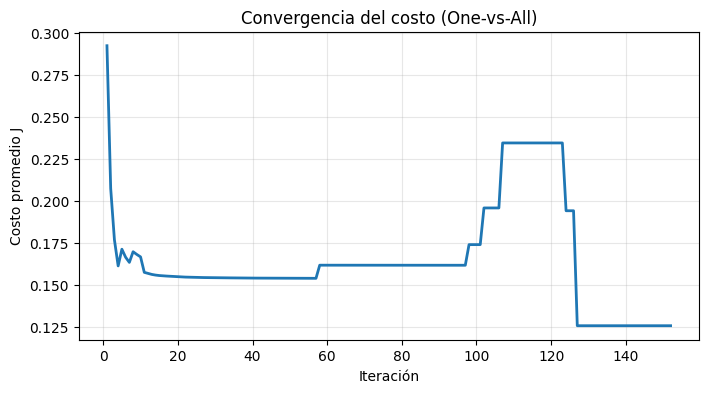

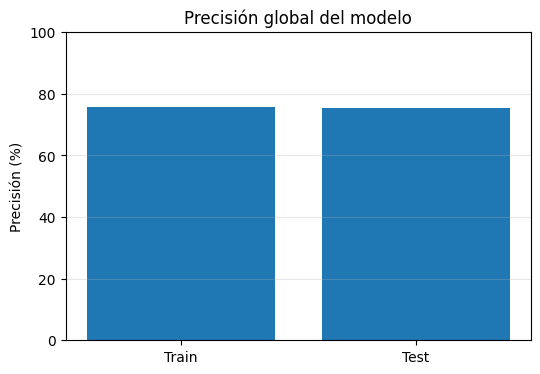

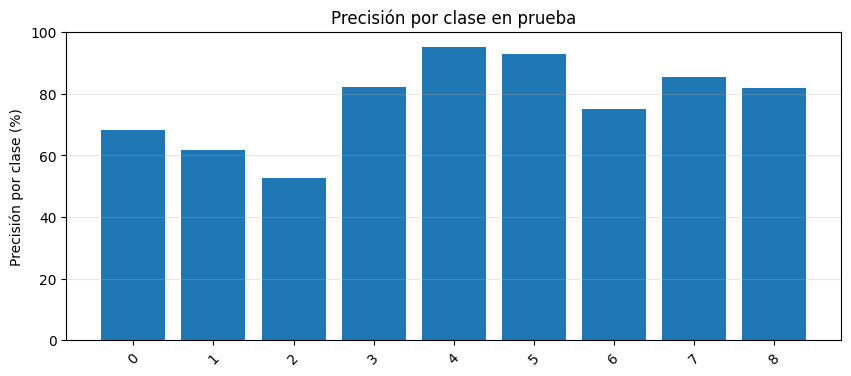

In [17]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Tenga en cuenta que X contiene los ejemplos en filas.
    all_theta es una matriz donde la i-ésima fila es un vector theta de regresión logística entrenada para la i-ésima clase.
    Debe establecer p en un vector de valores de 0..K-1 (por ejemplo, p = [0, 2, 0, 1]
    predice clases 0, 2, 0, 1 para 4 ejemplos).

    Parametros
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.

    X : array_like
        Data points to predict their labels. This is a matrix of shape
        (m x n) where m is number of data points to predict, and n is number
        of features without the bias term. Note we add the bias term for X in
        this function.

    Devuelve
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    idx_predictions = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)
    
    # ✅ Convertir índices a clases reales
    p = np.array([classes[i] for i in idx_predictions])

    return p

# ===============================
# Gráficas de costo y precisión
# ===============================

# Predicciones sobre entrenamiento y prueba
y_train_pred = predictOneVsAll(all_theta, X_train_norm)
y_test_pred = predictOneVsAll(all_theta, X_test_norm)

# Precisión global
acc_train = np.mean(y_train_pred == y_train) * 100
acc_test = np.mean(y_test_pred == y_test) * 100
print(f'Precisión entrenamiento: {acc_train:.2f}%')
print(f'Precisión prueba: {acc_test:.2f}%')

# Precisión por clase en prueba
prec = []
for c in range(num_labels):
    tp = np.sum((y_test_pred == classes[c]) & (y_test == classes[c]))
    fp = np.sum((y_test_pred == classes[c]) & (y_test != classes[c]))
    p_cls = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    prec.append(p_cls)

metric_df = pd.DataFrame({
    'Clase': classes,
    'Precision': prec
})
print(metric_df)

# Gráfica de costo promedio (promedio entre clases por iteración)
max_len = max(len(h) for h in cost_histories.values())
cost_matrix = np.full((num_labels, max_len), np.nan)
for c in range(num_labels):
    h = cost_histories[c]
    cost_matrix[c, :len(h)] = h
avg_cost = np.nanmean(cost_matrix, axis=0)

pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(1, len(avg_cost) + 1), avg_cost, lw=2)
pyplot.xlabel('Iteración')
pyplot.ylabel('Costo promedio J')
pyplot.title('Convergencia del costo (One-vs-All)')
pyplot.grid(True, alpha=0.3)
pyplot.show()

# Gráfica de precisión global train vs test
pyplot.figure(figsize=(6, 4))
pyplot.bar(['Train', 'Test'], [acc_train, acc_test])
pyplot.ylim(0, 100)
pyplot.ylabel('Precisión (%)')
pyplot.title('Precisión global del modelo')
pyplot.grid(axis='y', alpha=0.3)
pyplot.show()

# Gráfica de precisión por clase (test)
pyplot.figure(figsize=(10, 4))
pyplot.bar(metric_df['Clase'].astype(str), metric_df['Precision'] * 100)
pyplot.ylim(0, 100)
pyplot.ylabel('Precisión por clase (%)')
pyplot.title('Precisión por clase en prueba')
pyplot.xticks(rotation=45)
pyplot.grid(axis='y', alpha=0.3)
pyplot.show()